In [1]:
import numpy as np
import pandas as pd

***Here it cheks that raw data is encoded in which format so accordingly we can import/read that dataset***

In [2]:
import pandas as pd

try:
    df = pd.read_csv('spam.csv', encoding='utf-8')
    print("Loaded using UTF-8")

except UnicodeDecodeError:
    df = pd.read_csv('spam.csv', encoding='latin-1')
    print("Loaded using Latin-1")


Loaded using Latin-1


In [3]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
33,ham,For fear of fainting with the of all that hous...,NaN,NaN,NaN
2411,ham,"Come to me right now, Ahmad",NaN,NaN,NaN
770,ham,Not getting anywhere with this damn job huntin...,NaN,NaN,NaN
3715,ham,Networking technical support associate.,NaN,NaN,NaN
2517,ham,"Sorry, I'll call later",NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

## 1. All about what we are going to do in this project in this sequence
1. Data Cleaning 
2. EDA
3. Text Preprocessing
4. Model building 
5. Evaluation
6. Improvement
7. Website
8. Deploy

## 1. Data Cleaning

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [6]:
# Drop last 3 columns
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)

In [7]:
df.sample(5)

,v1,v2
3730,ham,Isn't frnd a necesity in life? imagine urself ...
2039,ham,Dont pack what you can buy at any store.like c...
2902,ham,Tell me pa. How is pain de.
3551,ham,Lol u still feeling sick?
4149,ham,I only work from mon to thurs but Sat i cant l...


In [8]:
# Renaming the columns
df.rename(columns={'v1' : 'target', 'v2' : 'text'}, inplace = True)
df.sample(5)

,target,text
4914,ham,We took hooch for a walk toaday and i fell ove...
3032,ham,"Aight, lemme know what's up"
1610,ham,I'll probably be around mu a lot
3377,ham,Hows that watch resizing
1797,ham,Can i get your opinion on something first?


### Here we were converting ham/spam into 0 or 1

In [9]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [10]:
df['target'] = encoder.fit_transform(df['target'])

In [11]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


### Check is there any missing value or not..?

In [12]:
df.isnull().sum()

target    0
text      0
dtype: int64

### Check is there any duplicate value or not..?

In [13]:
df.duplicated().sum()

np.int64(403)

In [14]:
# Drop the duplicate values..
df = df.drop_duplicates(keep='first')

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.shape

(5169, 2)

## 2. EDA

In [17]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [18]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

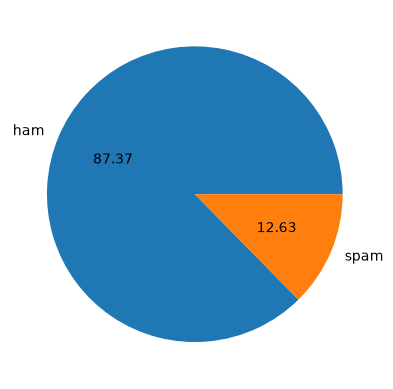

In [19]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['ham', 'spam'], autopct = "%0.2f")
plt.show()

### # One thing we got from this pie chart that our data is highly imbalanced

In [20]:
import nltk

In [21]:
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### Now we are going to create few extra columns 
1. Number of Characters
2. Number or words
3. Number of sentences

In [22]:
# Num of characters..?
df['num_characters'] = df['text'].apply(len)

In [23]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [24]:
# Num of words..?
df['num_words'] = df['text'].apply(lambda x : len(nltk.word_tokenize(x)))

In [25]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [26]:
# Num of sentences...?
df['num_sentences'] = df['text'].apply(lambda x : len(nltk.sent_tokenize(x)))

In [27]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [28]:
df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [29]:
# Analyzing ham seperately..
df[df['target'] == 0][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [30]:
# Analyzing spam seperately..
df[df['target'] == 1][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


### Now plot Histogram for Ham and Spam both

In [31]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

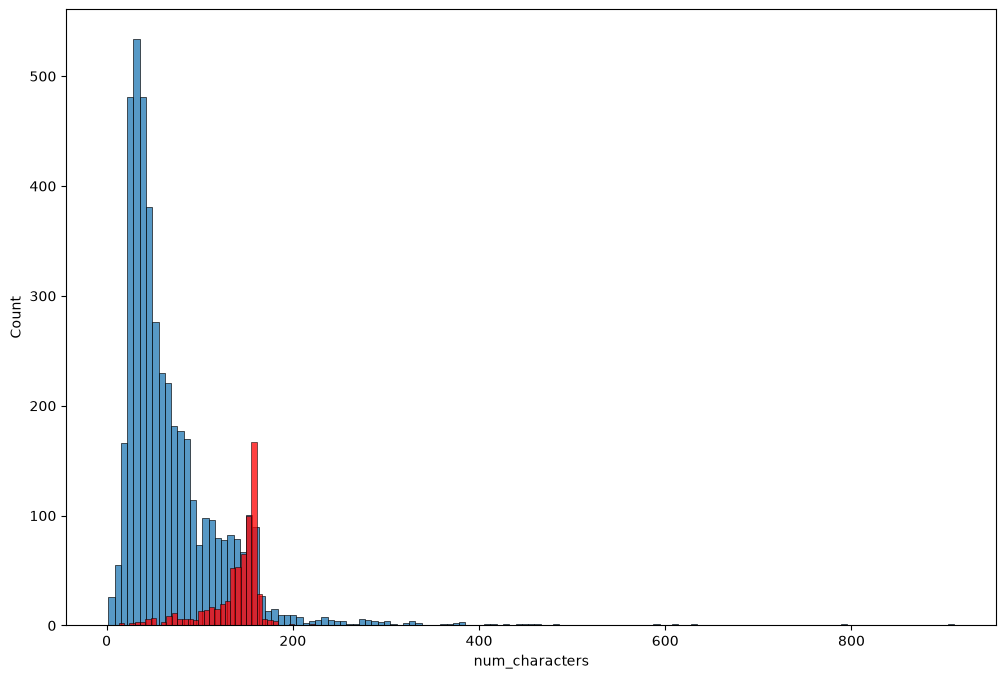

In [32]:
plt.figure(figsize = (12, 8))
sns.histplot(df[df['target'] ==0]['num_characters'])
sns.histplot(df[df['target'] ==1]['num_characters'], color = 'red')

<Axes: xlabel='num_words', ylabel='Count'>

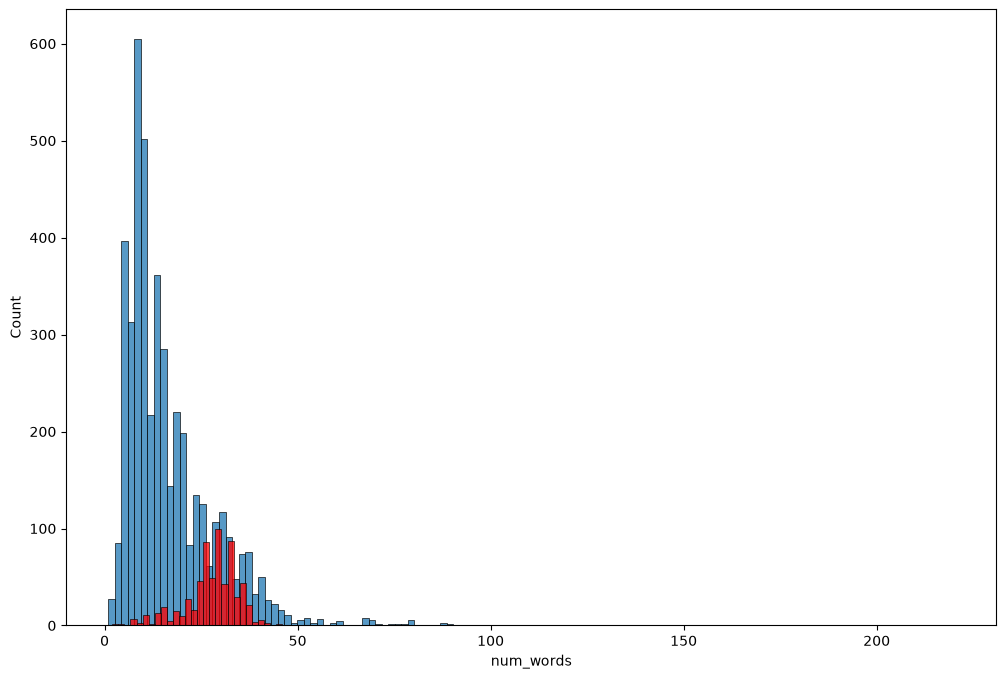

In [33]:
plt.figure(figsize = (12, 8))
sns.histplot(df[df['target'] ==0]['num_words'])
sns.histplot(df[df['target'] ==1]['num_words'], color = 'red')

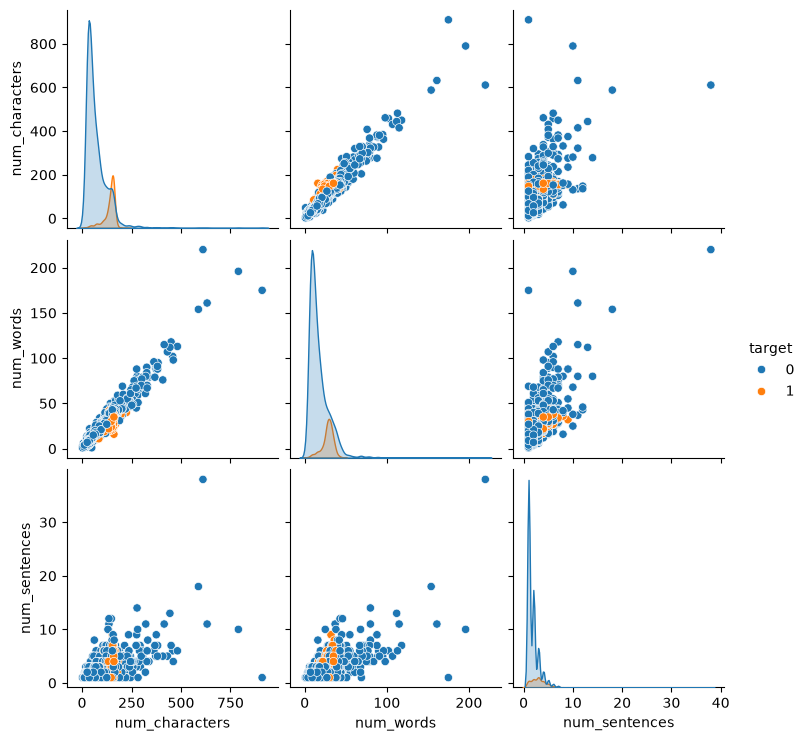

In [34]:
sns.pairplot(df, hue = 'target')

<Axes: >

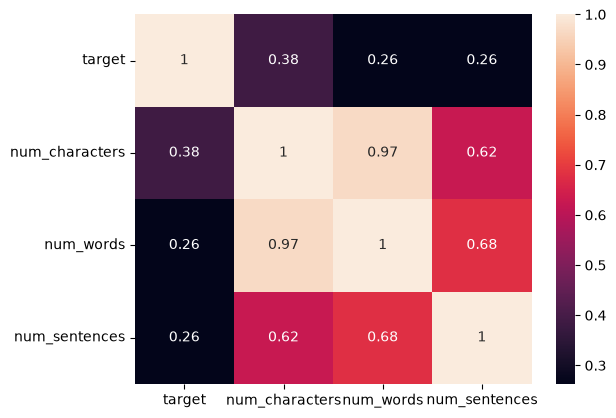

In [35]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

## 3. Data/Text Preprocessing
1. Lower case
2. Tokenization
3. Removing special characters
4. Removing stop words and punctuations
5. Stemming

***Now i am going to create a function which will perform all the steps together***

In [36]:
# Here we will perform stemming 
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('Loving')

'love'

In [37]:
def transform_text(text):
    text = text.lower()  # it is converting is lower case
    text = nltk.word_tokenize(text)  # converting words into token

    # so from here text is converted in a list so now we will run a loop

    # removing alpha numeric characters
    y = []
    for i in text :
        if i.isalnum():
            y.append(i)


    # Here we were removing stopwords and punctuations..
    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)


    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)

In [38]:
from nltk.corpus import stopwords

In [39]:
# These are all our punctuations 
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [40]:
transform_text('I love the Youtube lectures on ML. How about you..?')

'love youtub lectur ml'

In [41]:
df['transformed_text'] = df['text'].apply(transform_text)

In [42]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


***Now we are going to create word cloud for Spam message***

In [43]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [44]:
from wordcloud import WordCloud
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

In [45]:
spam_wc = wc.generate(df[df['target'] == 1] ['transformed_text'].str.cat(sep=" "))

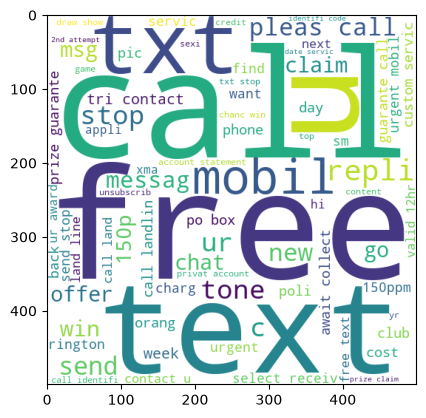

In [46]:
plt.Figure(figsize=(15, 6))
plt.imshow(spam_wc)

***Now we are going to create word cloud for Ham message***

In [47]:
ham_wc = wc.generate(df[df['target'] == 0] ['transformed_text'].str.cat(sep=" "))

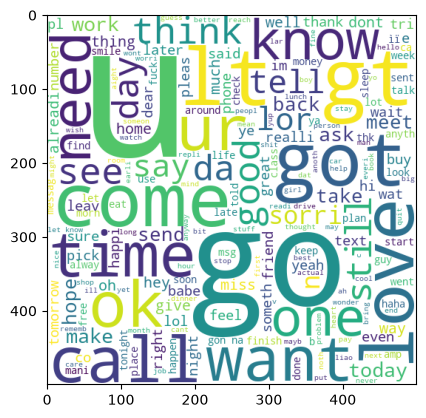

In [48]:
plt.Figure(figsize=(15, 6))
plt.imshow(ham_wc)

### Now we write the custom code to find top 50 words in Ham and Spam message 

In [49]:
df.head(3)

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...


In [50]:
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [51]:
len(spam_corpus)

9939

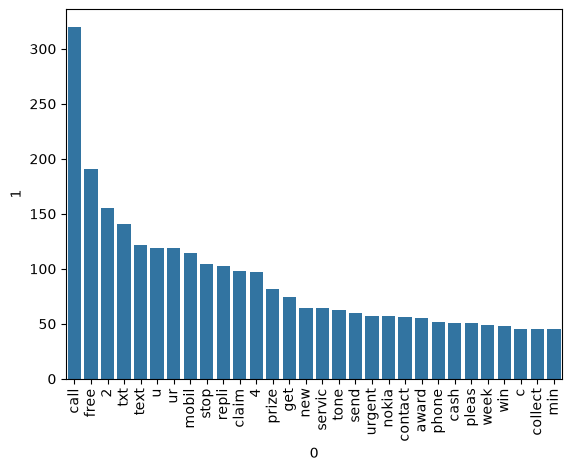

In [52]:
from collections import Counter

data = pd.DataFrame(Counter(spam_corpus).most_common(30))

sns.barplot(x=data[0], y=data[1])
plt.xticks(rotation='vertical')
plt.show()

In [53]:
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [54]:
len(ham_corpus)

35404

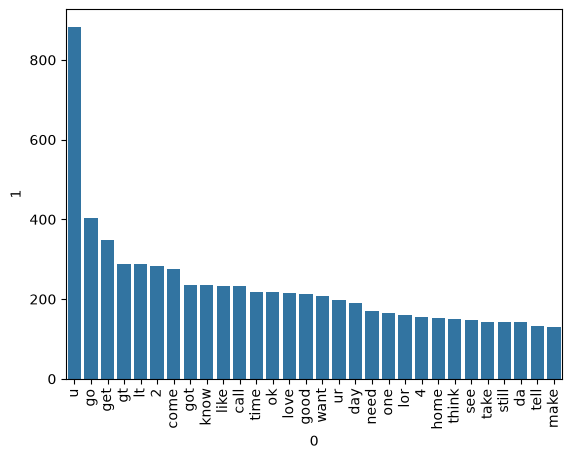

In [55]:
from collections import Counter

data = pd.DataFrame(Counter(ham_corpus).most_common(30))

sns.barplot(x=data[0], y=data[1])
plt.xticks(rotation='vertical')
plt.show()

## 4. Model Building

In [85]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [86]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [87]:
X.shape

(5169, 3000)

In [88]:
y = df['target'].values

In [89]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

**Now we will train Model**

In [90]:
from sklearn.model_selection import train_test_split

In [91]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [92]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [93]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

**Here we will check on Gaussina naive_bayes**

In [94]:
gnb.fit(X_train, y_train)
y_pred1 = gnb.predict(X_test)
print("Accuracy : ", accuracy_score(y_test, y_pred1))
print("Confusion Matrix : ", confusion_matrix(y_test, y_pred1))
print("Precisoin Score : ", precision_score(y_test, y_pred1))

Accuracy :  0.874274661508704
Confusion Matrix :  [[790 106]
 [ 24 114]]
Precisoin Score :  0.5181818181818182


**Here we will check on Multinomial naive_bayes**

In [95]:
mnb.fit(X_train, y_train)
y_pred2 = mnb.predict(X_test)
print("Accuracy : ", accuracy_score(y_test, y_pred2))
print("Confusion Matrix : ", confusion_matrix(y_test, y_pred2))
print("Precisoin Score : ", precision_score(y_test, y_pred2))

Accuracy :  0.9709864603481625
Confusion Matrix :  [[896   0]
 [ 30 108]]
Precisoin Score :  1.0


**Here we will check on Bernouli naive_bayes**

In [96]:
bnb.fit(X_train, y_train)
y_pred3 = bnb.predict(X_test)
print("Accuracy : ", accuracy_score(y_test, y_pred3))
print("Confusion Matrix : ", confusion_matrix(y_test, y_pred3))
print("Precisoin Score : ", precision_score(y_test, y_pred3))

Accuracy :  0.9835589941972921
Confusion Matrix :  [[895   1]
 [ 16 122]]
Precisoin Score :  0.991869918699187


### So, here we have selected tfidf --> multinomial naive_bayes (it is giving us best precisoon value)

***Now we are going to train our model with different ML nodels and compare***

In [97]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [98]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50, random_state=2)
xgb = XGBClassifier(n_estimators=50, random_state=2)

In [99]:
clfs = {
    'SVC' : svc,
    'KN' : knc,
    'NB' : mnb,
    'DT' : dtc,
    'LR' : lrc,
    'RF' : rfc,
    'AdaBoost' : abc,
    'BgC' : bc,
    'ETC' : etc,
    'GBDT' : gbdt,
    'xgb' : xgb
}

In [100]:
def  train_classifier(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)

    return accuracy, precision

In [101]:
train_classifier(svc, X_train, y_train, X_test, y_test)

(0.9758220502901354, 0.9747899159663865)

***Here we will run a loop which calculates precision and accuracy iterately for all algorithms***

In [102]:
accuracy_scores = []
precision_scores = []

for name, clf in clfs.items():
    current_accuracy, current_precision = train_classifier(clf, X_train, y_train, X_test, y_test)

    print("for ", name )
    print("Accuracy - ", current_accuracy)
    print("Precision - ", current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

for  SVC
Accuracy -  0.9758220502901354
Precision -  0.9747899159663865
for  KN
Accuracy -  0.9052224371373307
Precision -  1.0
for  NB
Accuracy -  0.9709864603481625
Precision -  1.0
for  DT
Accuracy -  0.9303675048355899
Precision -  0.83
for  LR
Accuracy -  0.9555125725338491
Precision -  0.96


c:\Users\LENOVO\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\LENOVO\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


for  RF
Accuracy -  0.9738878143133463
Precision -  0.9826086956521739
for  AdaBoost
Accuracy -  0.9216634429400387
Precision -  0.8202247191011236
for  BgC
Accuracy -  0.9584139264990329
Precision -  0.8682170542635659
for  ETC
Accuracy -  0.9748549323017408
Precision -  0.9745762711864406
for  GBDT
Accuracy -  0.9506769825918762
Precision -  0.9306930693069307
for  xgb
Accuracy -  0.9700193423597679
Precision -  0.9572649572649573


**Here we will create a Dataframe in which we store the precision and accuracy of the models(Trained on all the algorithm)**

In [74]:
performance_df = pd.DataFrame({'Algorithm' : clfs.keys(), 'Accuracy' : accuracy_scores, 'Precision' : precision_scores}).sort_values('Precision', ascending=False)

In [75]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.900387,1.000000
2,NB,0.959381,1.000000
5,RF,0.971954,1.000000
8,ETC,0.972921,0.982456
0,SVC,0.972921,0.974138
10,xgb,0.970986,0.942623
4,LR,0.951644,0.940000
9,GBDT,0.951644,0.923077
7,BgC,0.958414,0.862595
6,AdaBoost,0.924565,0.840909


**NOw we will convert our dataframe from wide format to long format (Because, It is especially useful when making plots with Seaborn)**

In [76]:
performance_df1 = pd.melt(performance_df, id_vars="Algorithm")

In [77]:
performance_df1

,Algorithm,variable,value
0,KN,Accuracy,0.900387
1,NB,Accuracy,0.959381
2,RF,Accuracy,0.971954
3,ETC,Accuracy,0.972921
4,SVC,Accuracy,0.972921
5,xgb,Accuracy,0.970986
6,LR,Accuracy,0.951644
7,GBDT,Accuracy,0.951644
8,BgC,Accuracy,0.958414
9,AdaBoost,Accuracy,0.924565


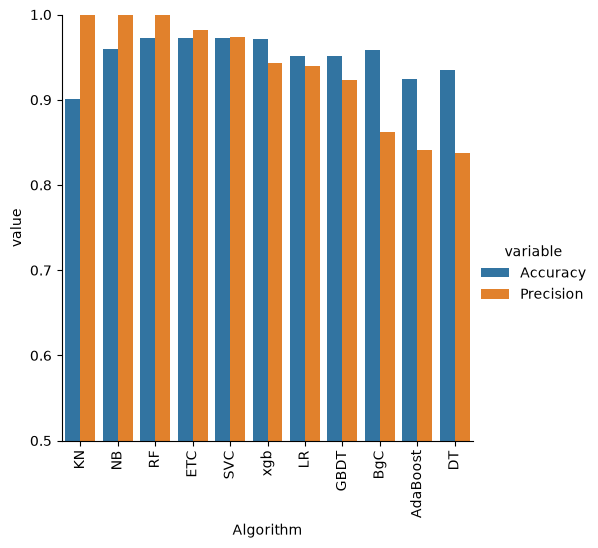

In [84]:
sns.catplot(
    data=performance_df1,
    x="Algorithm",
    y="value",
    hue="variable",
    kind="bar",
    height=5
)

plt.ylim(0.5, 1.0)
plt.xticks(rotation='vertical')
plt.show()

### From here Onwards we will work on model imprivement
1. Change the max_feature parameter of TFIDF 

In [103]:
temp_df = pd.DataFrame({'Algorithm' : clfs.keys(), 'Accuracy_max_fit_3000' : accuracy_scores, 'Precision_max_fit_3000' : precision_scores})

In [104]:
performance_df.merge(temp_df, on = 'Algorithm')

,Algorithm,Accuracy,Precision,Accuracy_max_fit_3000,Precision_max_fit_3000
0,KN,0.900387,1.000000,0.905222,1.000000
1,NB,0.959381,1.000000,0.970986,1.000000
2,RF,0.971954,1.000000,0.973888,0.982609
3,ETC,0.972921,0.982456,0.974855,0.974576
4,SVC,0.972921,0.974138,0.975822,0.974790
5,xgb,0.970986,0.942623,0.970019,0.957265
6,LR,0.951644,0.940000,0.955513,0.960000
7,GBDT,0.951644,0.923077,0.950677,0.930693
8,BgC,0.958414,0.862595,0.958414,0.868217
9,AdaBoost,0.924565,0.840909,0.921663,0.820225


In [105]:
import pickle
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))
pickle.dump(mnb, open('model.pkl', 'wb'))